In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, silhouette_score


np.random.seed(42)

print("CLUSTERING MERGED DATASET (RED VS WHITE)")

file_path = 'winedata.xlsx'
red_df = pd.read_excel(file_path, sheet_name='Red Wine')
white_df = pd.read_excel(file_path, sheet_name='White Wine')

red_df['wine_type'] = 0
white_df['wine_type'] = 1

merged_df = pd.concat([red_df, white_df], ignore_index=True)

X_obj1 = merged_df.iloc[:, :11]
y_true_type = merged_df['wine_type']

#missing values check
merged_df_missing = merged_df.isnull().sum()
print("\n--- Missing Values Check ---")
print(merged_df_missing)

scaler_obj1 = StandardScaler()
X_obj1_scaled = scaler_obj1.fit_transform(X_obj1)
print("\n--- Data Scaling (Standardized) ---")
print(X_obj1_scaled)



CLUSTERING MERGED DATASET (RED VS WHITE)

--- Missing Values Check ---
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
wine_type               0
dtype: int64

--- Data Scaling (Standardized) ---
[[ 0.14247327  2.18883292 -2.19283252 ...  1.81308951  0.19309677
  -0.91546416]
 [ 0.45103572  3.28223494 -2.19283252 ... -0.11507303  0.99957862
  -0.58006813]
 [ 0.45103572  2.55330026 -1.91755268 ...  0.25811972  0.79795816
  -0.58006813]
 ...
 [-0.55179227 -0.6054167  -0.88525328 ... -1.42124765 -0.47897144
  -0.91546416]
 [-1.32319841 -0.30169391 -0.12823371 ...  0.75571005 -1.016626
   1.9354021 ]
 [-0.93749534 -0.78765037  0.42232597 ...  0.25811972 -1.41986693
   1.09691202]]


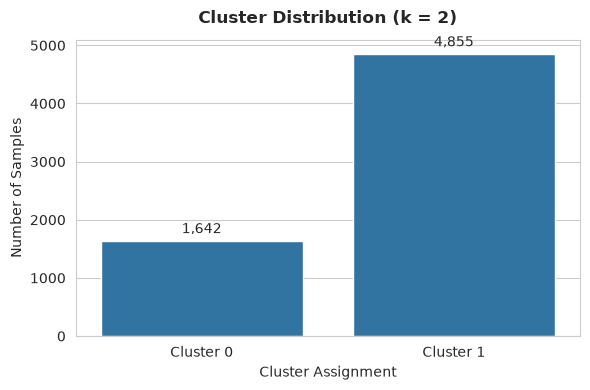

In [70]:
#K-Means Clustering (k = 2)

kmeans_obj1 = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels_obj1 = kmeans_obj1.fit_predict(X_obj1_scaled)

accuracy_raw = accuracy_score(y_true_type, cluster_labels_obj1)
if accuracy_raw < 0.5:
    aligned_labels_obj1 = 1 - cluster_labels_obj1
else:
    aligned_labels_obj1 = cluster_labels_obj1

plt.figure(figsize=(6, 4))
ax = sns.countplot(x=aligned_labels_obj1)

plt.title('Cluster Distribution (k = 2)', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Cluster Assignment', fontsize=10)
plt.ylabel('Number of Samples', fontsize=10)
plt.xticks([0, 1], ['Cluster 0', 'Cluster 1'])


for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, xytext=(0, 3), 
                textcoords='offset points')

plt.tight_layout()
plt.show()


--- Confusion Matrix ---
                  Predicted Red (0)  Predicted White (1)
Actual Red (0)                 1575                   24
Actual White (1)                 67                 4831


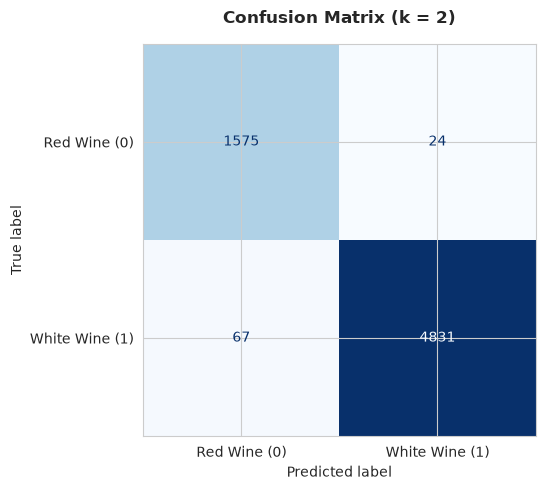


--- Performance Metrics ---
Classification Accuracy : 98.60%
Sensitivity (White Wine): 98.63%


In [74]:
cm_obj1 = confusion_matrix(y_true_type, aligned_labels_obj1)
acc_obj1 = accuracy_score(y_true_type, aligned_labels_obj1)

sensitivity_obj1 = recall_score(y_true_type, aligned_labels_obj1, pos_label=1)

#confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm_df = pd.DataFrame(
    cm_obj1,
    index=['Actual Red (0)', 'Actual White (1)'],
    columns=['Predicted Red (0)', 'Predicted White (1)']
)

print("\n--- Confusion Matrix ---")
print(cm_df)

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_obj1,
    display_labels=['Red Wine (0)', 'White Wine (1)']
)

disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False)
plt.title('Confusion Matrix (k = 2)', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\n--- Performance Metrics ---")
print(f"Classification Accuracy : {acc_obj1 * 100:.2f}%")
print(f"Sensitivity (White Wine): {sensitivity_obj1 * 100:.2f}%")



CLUSTERING WHITE WINES ONLY


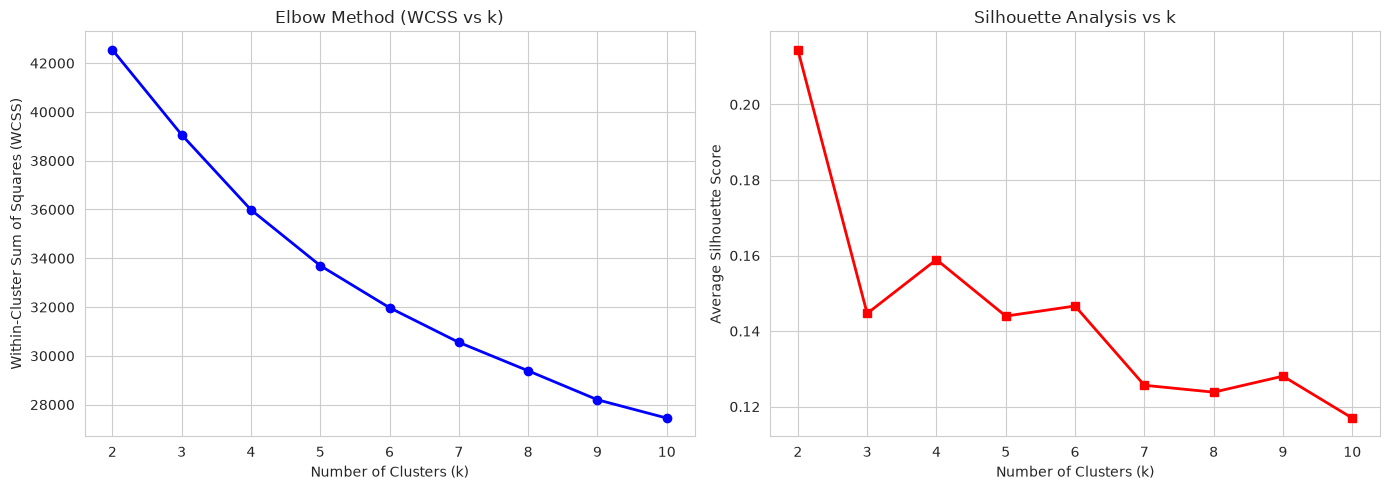


--- Silhouette Scores for Candidate Evaluation ---
k =  2 | Silhouette Score = 0.2145
k =  3 | Silhouette Score = 0.1447
k =  4 | Silhouette Score = 0.1589
k =  5 | Silhouette Score = 0.1440
k =  6 | Silhouette Score = 0.1466
k =  7 | Silhouette Score = 0.1257
k =  8 | Silhouette Score = 0.1238
k =  9 | Silhouette Score = 0.1281
k = 10 | Silhouette Score = 0.1170


In [72]:


# White Wine Dataset Analysis
print("CLUSTERING WHITE WINES ONLY")

X_white = white_df.iloc[:, :11]
y_white_quality = white_df['quality']

scaler_obj2 = StandardScaler()
X_white_scaled = scaler_obj2.fit_transform(X_white)

wcss = []
silhouette_avg_list = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_white_scaled)
    wcss.append(km.inertia_)
    
    # Calculate silhouette score
    sil = silhouette_score(X_white_scaled, labels)
    silhouette_avg_list.append(sil)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Elbow Method
ax1.plot(k_range, wcss, marker='o', color='b', linewidth=2)
ax1.set_title('Elbow Method (WCSS vs k)', fontsize=12)
ax1.set_xlabel('Number of Clusters (k)', fontsize=10)
ax1.set_ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=10)
ax1.grid(True)

ax2.plot(k_range, silhouette_avg_list, marker='s', color='r', linewidth=2)
ax2.set_title('Silhouette Analysis vs k', fontsize=12)
ax2.set_xlabel('Number of Clusters (k)', fontsize=10)
ax2.set_ylabel('Average Silhouette Score', fontsize=10)
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\n--- Silhouette Scores for Candidate Evaluation ---")
for k, score in zip(k_range, silhouette_avg_list):
    print(f"k = {k:2d} | Silhouette Score = {score:.4f}")



Top Two Selected Candidate Cluster Numbers: k = 2 and k = 4

--- Candidate Validation ---
Candidate 1 (k = 2): Silhouette Score = 0.2145
Candidate 2 (k = 4): Silhouette Score = 0.1589

>>> Winning Test Selected: k = 2 <<<

--- Mean of Each Attribute per Group (Winning Model) ---
Cluster                      0         1
fixed acidity           7.0032    6.7560
volatile acidity        0.2830    0.2751
citric acid             0.3625    0.3153
residual sugar         10.6921    3.5296
chlorides               0.0545    0.0400
free sulfur dioxide    45.4650   28.5495
total sulfur dioxide  170.8975  116.7100
density                 0.9969    0.9921
pH                      3.1578    3.2085
sulphates               0.4967    0.4853
alcohol                 9.5412   11.1618

--- Consistency Check with Column 12 (Quality Score) ---
 Cluster  Mean_Quality  Median_Quality  Std_Dev  Count
       0      5.603475             6.0 0.762187   1957
       1      6.060524             6.0 0.914588   2941


/tmp/ipykernel_12352/973079607.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='quality', data=white_df, palette='Set2')


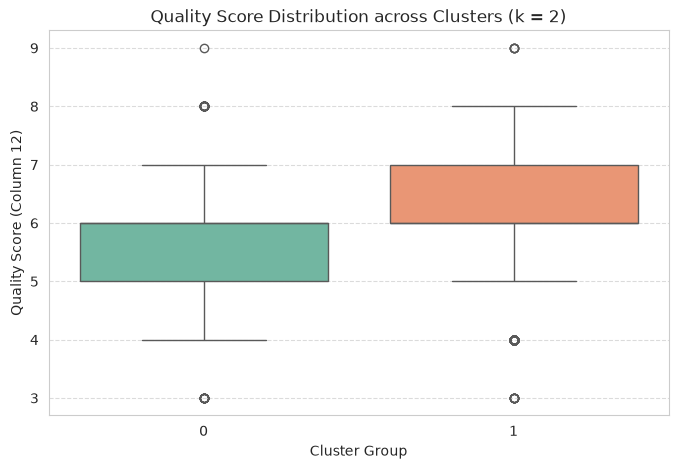

In [73]:

top_k_indices = np.argsort(silhouette_avg_list)[-2:][::-1]
cand1_k = list(k_range)[top_k_indices[0]]
cand2_k = list(k_range)[top_k_indices[1]]

print(f"\nTop Two Selected Candidate Cluster Numbers: k = {cand1_k} and k = {cand2_k}")

# Perform K-Means for both candidates
km_cand1 = KMeans(n_clusters=cand1_k, random_state=42, n_init=10).fit(X_white_scaled)
km_cand2 = KMeans(n_clusters=cand2_k, random_state=42, n_init=10).fit(X_white_scaled)

score_cand1 = silhouette_score(X_white_scaled, km_cand1.labels_)
score_cand2 = silhouette_score(X_white_scaled, km_cand2.labels_)

print("\n--- Candidate Validation ---")
print(f"Candidate 1 (k = {cand1_k}): Silhouette Score = {score_cand1:.4f}")
print(f"Candidate 2 (k = {cand2_k}): Silhouette Score = {score_cand2:.4f}")

if score_cand1 >= score_cand2:
    winning_k = cand1_k
    winning_model = km_cand1
else:
    winning_k = cand2_k
    winning_model = km_cand2

print(f"\n>>> Winning Test Selected: k = {winning_k} <<<")

white_df['Cluster'] = winning_model.labels_


attribute_cols = white_df.columns[:11]
attribute_means = white_df.groupby('Cluster')[attribute_cols].mean()

print("\n--- Mean of Each Attribute per Group (Winning Model) ---")
print(attribute_means.T.round(4))

quality_consistency = white_df.groupby('Cluster')['quality'].agg(
    Mean_Quality='mean',
    Median_Quality='median',
    Std_Dev='std',
    Count='count'
).reset_index()

print("\n--- Consistency Check with Column 12 (Quality Score) ---")
print(quality_consistency.to_string(index=False))


plt.figure(figsize=(8, 5))
sns.boxplot(x='Cluster', y='quality', data=white_df, palette='Set2')
plt.title(f'Quality Score Distribution across Clusters (k = {winning_k})', fontsize=12)
plt.xlabel('Cluster Group', fontsize=10)
plt.ylabel('Quality Score (Column 12)', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()